# 🧠 Simple Diffusion Walkthrough

Welcome to the walked example for **Denoising Diffusion Probabilistic Models (DDPM)** and **Denoising Diffusion Implicit Models (DDIM)**. This notebook will guide you through the mathematical intuition and the code implementation.

## 1. The Forward Process (Adding Noise)
In diffusion models, we gradually add Gaussian noise to the data $x_0$ over $T$ steps.

The noise addition at a single step is defined as:
$$ q(x_t | x_{t-1}) = \mathcal{N}(x_t; \sqrt{1 - \beta_t} x_{t-1}, \beta_t I) $$

Thanks to the reparameterization trick, we can jump directly to step $t$ without iterating:
$$ q(x_t | x_0) = \mathcal{N}(x_t; \sqrt{\bar{\alpha}_t} x_0, (1 - \bar{\alpha}_t) I) $$
where $\alpha_t = 1 - \beta_t$ and $\bar{\alpha}_t = \prod_{s=1}^t \alpha_s$.

### 🎨 Diagram: Forward vs Backward
```mermaid
graph LR
    x0[Image x_0] -->|q Add Noise| x1[x_1]
    x1 -->|q Add Noise| xt[x_t]
    xt -->|q Add Noise| xT[Noise x_T]
    
    xT -.->|p Denoise| xt
    xt -.->|p Denoise| x1
    x1 -.->|p Denoise| x0
```

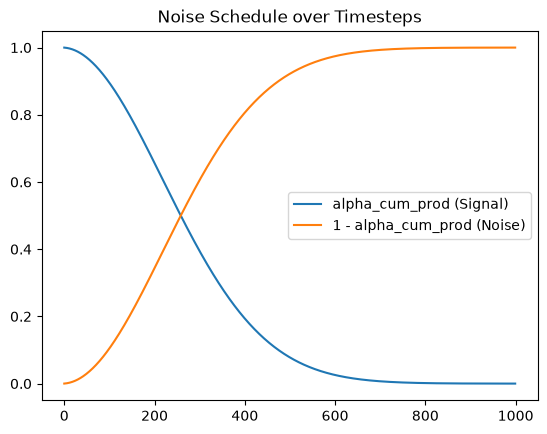

In [2]:
import torch
import matplotlib.pyplot as plt

# Let's visualize the beta and alpha schedules
num_timesteps = 1000
beta_start = 0.0001
beta_end = 0.02

betas = torch.linspace(beta_start, beta_end, num_timesteps)
alphas = 1. - betas
alpha_cum_prod = torch.cumprod(alphas, dim=0)

plt.plot(alpha_cum_prod.numpy(), label='alpha_cum_prod (Signal)')
plt.plot((1 - alpha_cum_prod).numpy(), label='1 - alpha_cum_prod (Noise)')
plt.title('Noise Schedule over Timesteps')
plt.legend()
plt.show()

## 2. The Backward Process (DDPM)
To reverse the process, we use a Neural Network (UNet) $\epsilon_\theta(x_t, t)$ to predict the noise added to the image.

The DDPM sampling step is:
$$ x_{t-1} = \frac{1}{\sqrt{\alpha_t}} \left( x_t - \frac{\beta_t}{\sqrt{1 - \bar{\alpha}_t}} \epsilon_\theta(x_t) \right) + \sigma_t z $$

Where $z \sim \mathcal{N}(0, I)$ and $\sigma_t$ is the variance.

In [3]:
import sys
import os
sys.path.append(os.path.abspath('..')) # Add src to path

from src.linear_noise_scheduler import LinearNoiseScheduler

ddpm_scheduler = LinearNoiseScheduler(num_timesteps, beta_start, beta_end)

# Dummy inference
xt = torch.randn(1, 3, 32, 32) # pure noise
t = torch.tensor([999])

# Dummy noise prediction from UNet
noise_pred = torch.randn(1, 3, 32, 32)

mean, x0_pred = ddpm_scheduler.sample_prev_timestep(xt, noise_pred, t)
print("DDPM next step shape:", mean.shape)

DDPM next step shape: torch.Size([1, 3, 32, 32])


## 3. Accelerated Sampling (DDIM)
DDIM generalized the sampling process to be non-Markovian, which allows us to skip steps! 

The DDIM update rule is:
$$ x_{t-1} = \sqrt{\bar{\alpha}_{t-1}} \underbrace{\left( \frac{x_t - \sqrt{1 - \bar{\alpha}_t} \epsilon_\theta(x_t)}{\sqrt{\bar{\alpha}_t}} \right)}_{\text{Predicted } x_0} + \underbrace{\sqrt{1 - \bar{\alpha}_{t-1} - \sigma_t^2} \cdot \epsilon_\theta(x_t)}_{\text{Direction to } x_t} + \sigma_t \epsilon $$

If $\sigma_t = 0$, the sampling process becomes deterministic, and we can generate images much faster.

In [4]:
from src.ddim_noise_scheduler import DDIM_NoiseScheduler

ddim_scheduler = DDIM_NoiseScheduler(num_timesteps, beta_start, beta_end)

# We can jump from t=999 to prev_t=900!
t = 999
prev_t = 900

prev_xt = ddim_scheduler.sample_prev_timestep(xt, noise_pred, t, prev_t)
print("DDIM jumped step shape:", prev_xt.shape)

DDIM jumped step shape: torch.Size([1, 3, 32, 32])
